<a href="https://colab.research.google.com/github/Kumarsakthi835/Python-DA-Data-Visualization/blob/main/Python_Data_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Load Dataset and Handle Missing Values
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = sns.load_dataset("taxis")
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (6433, 14)

First 5 rows:
               pickup             dropoff  passengers  distance  fare   tip  \
0 2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0  2.15   
1 2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0  0.00   
2 2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5  2.36   
3 2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0  6.15   
4 2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0  1.10   

   tolls  total   color      payment            pickup_zone  \
0    0.0  12.95  yellow  credit card        Lenox Hill West   
1    0.0   9.30  yellow         cash  Upper West Side South   
2    0.0  14.16  yellow  credit card          Alphabet City   
3    0.0  36.95  yellow  credit card              Hudson Sq   
4    0.0  13.40  yellow  credit card           Midtown East   

            dropoff_zone pickup_borough dropoff_borough  
0    UN/Turtle Bay South      Manhattan       M

In [3]:
#Handle Missing Values

#Categorical columns with mode
df['payment'] = df['payment'].fillna(df['payment'].mode()[0])
df['pickup_zone'] = df['pickup_zone'].fillna(df['pickup_zone'].mode()[0])
df['dropoff_zone'] = df['dropoff_zone'].fillna(df['dropoff_zone'].mode()[0])
df['pickup_borough'] = df['pickup_borough'].fillna(df['pickup_borough'].mode()[0])
df['dropoff_borough'] = df['dropoff_borough'].fillna(df['dropoff_borough'].mode()[0])

print("Missing Values After Handling:")
print(df.isnull().sum())

Missing Values After Handling:
pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


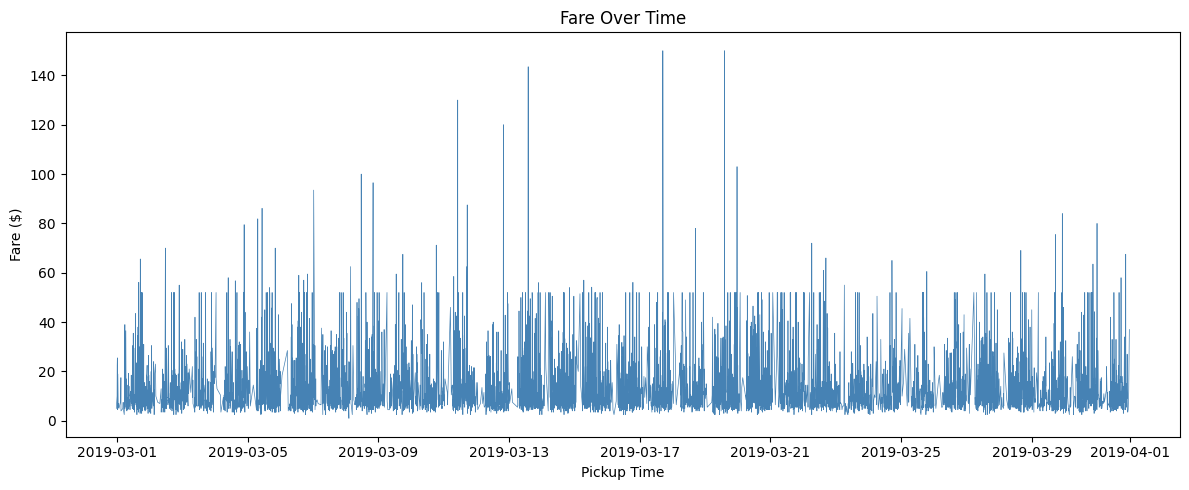

In [4]:
#Line Chart
df['pickup'] = pd.to_datetime(df['pickup'])
df_sorted = df.sort_values('pickup')

plt.figure(figsize=(12, 5))
plt.plot(df_sorted['pickup'], df_sorted['fare'], color='steelblue', linewidth=0.5)
plt.title('Fare Over Time')
plt.xlabel('Pickup Time')
plt.ylabel('Fare ($)')
plt.tight_layout()
plt.show()

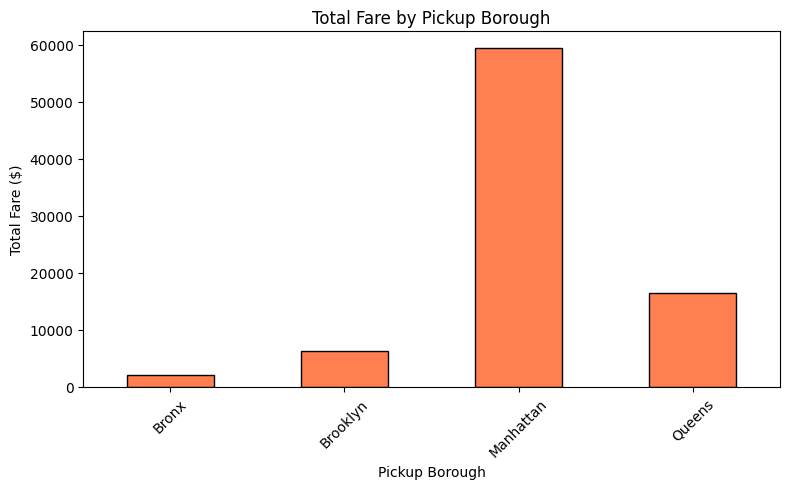

In [5]:
# Bar Chart
borough_fare = df.groupby('pickup_borough')['fare'].sum()

plt.figure(figsize=(8, 5))
borough_fare.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Total Fare by Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Total Fare ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

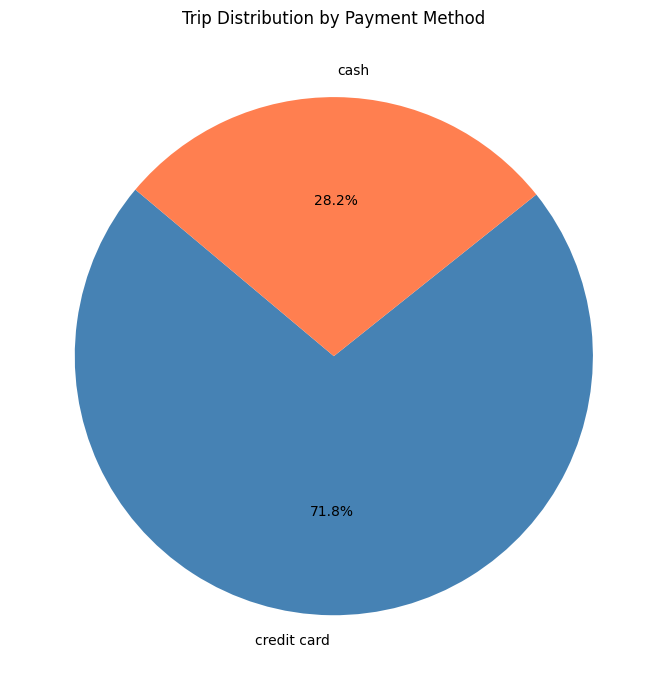

In [6]:
#Pie Chart
payment_counts = df['payment'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(payment_counts, labels=payment_counts.index,
        autopct='%1.1f%%', startangle=140,
        colors=['steelblue', 'coral', 'green', 'orange'])
plt.title('Trip Distribution by Payment Method')
plt.tight_layout()
plt.show()

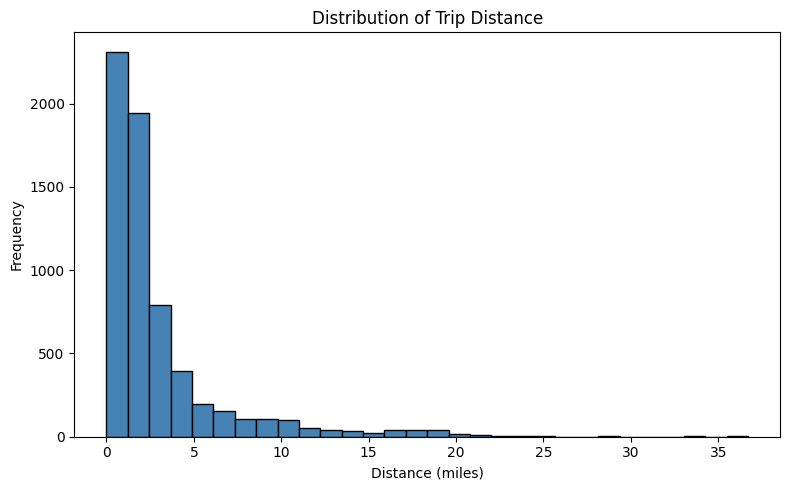

In [7]:
#Histogram
plt.figure(figsize=(8, 5))
plt.hist(df['distance'], bins=30, color='steelblue',
         edgecolor='black')
plt.title('Distribution of Trip Distance')
plt.xlabel('Distance (miles)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

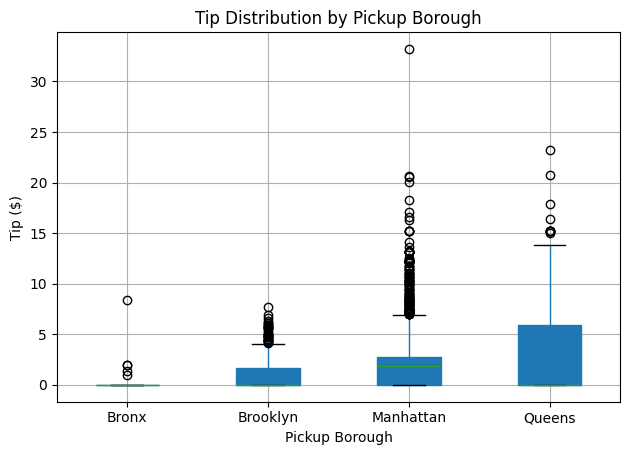

In [8]:
#Box Plot
plt.figure(figsize=(10, 6))
df.boxplot(column='tip', by='pickup_borough',
           patch_artist=True)
plt.title('Tip Distribution by Pickup Borough')
plt.suptitle('')
plt.xlabel('Pickup Borough')
plt.ylabel('Tip ($)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1328/1826276072.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='pickup_borough',


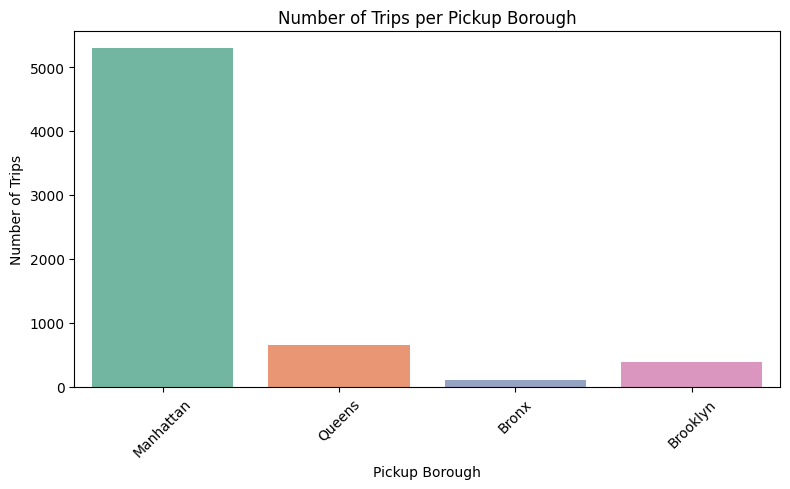

In [9]:
#Count Plot
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='pickup_borough',
              palette='Set2')
plt.title('Number of Trips per Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

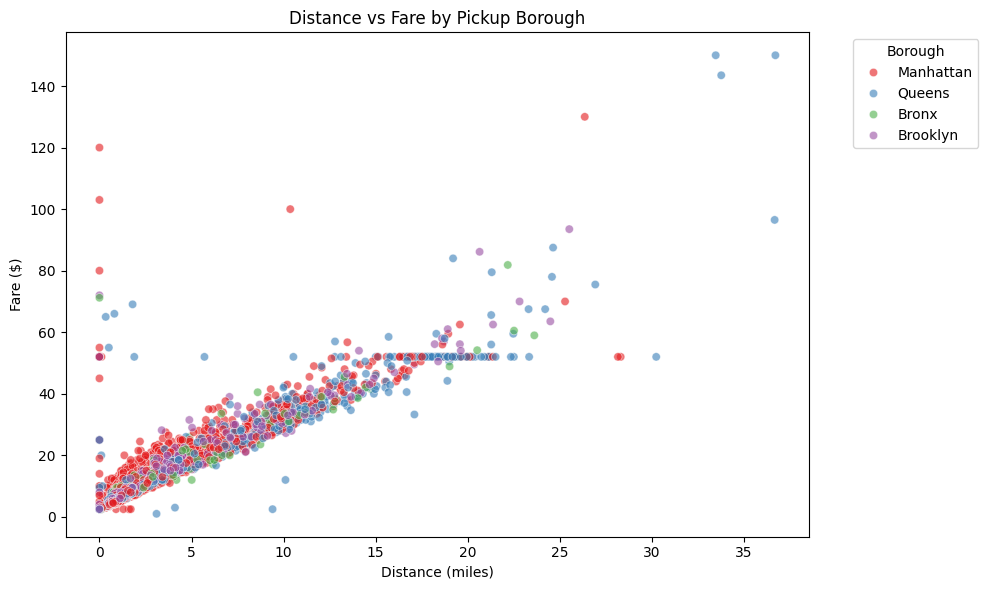

In [10]:
#Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='distance', y='fare',
                hue='pickup_borough', palette='Set1',
                alpha=0.6)
plt.title('Distance vs Fare by Pickup Borough')
plt.xlabel('Distance (miles)')
plt.ylabel('Fare ($)')
plt.legend(title='Borough', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

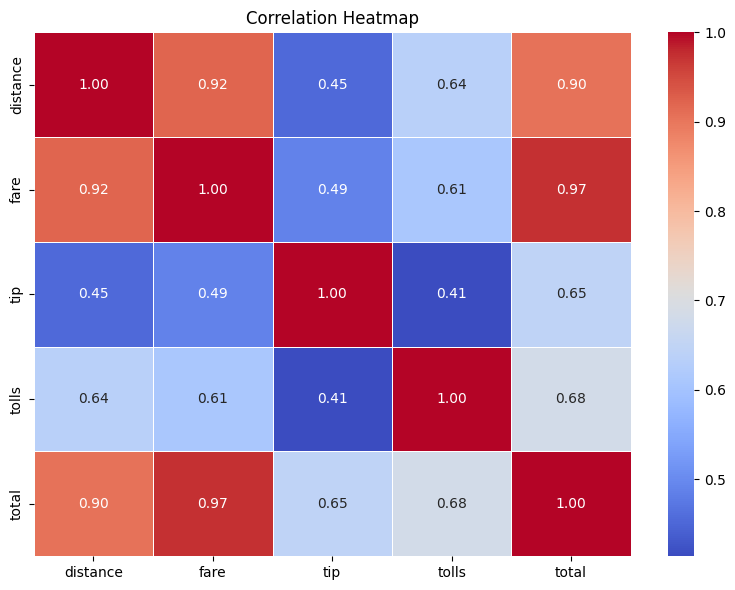

In [11]:
#Heatmap
plt.figure(figsize=(8, 6))
corr = df[['distance', 'fare', 'tip', 'tolls', 'total']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

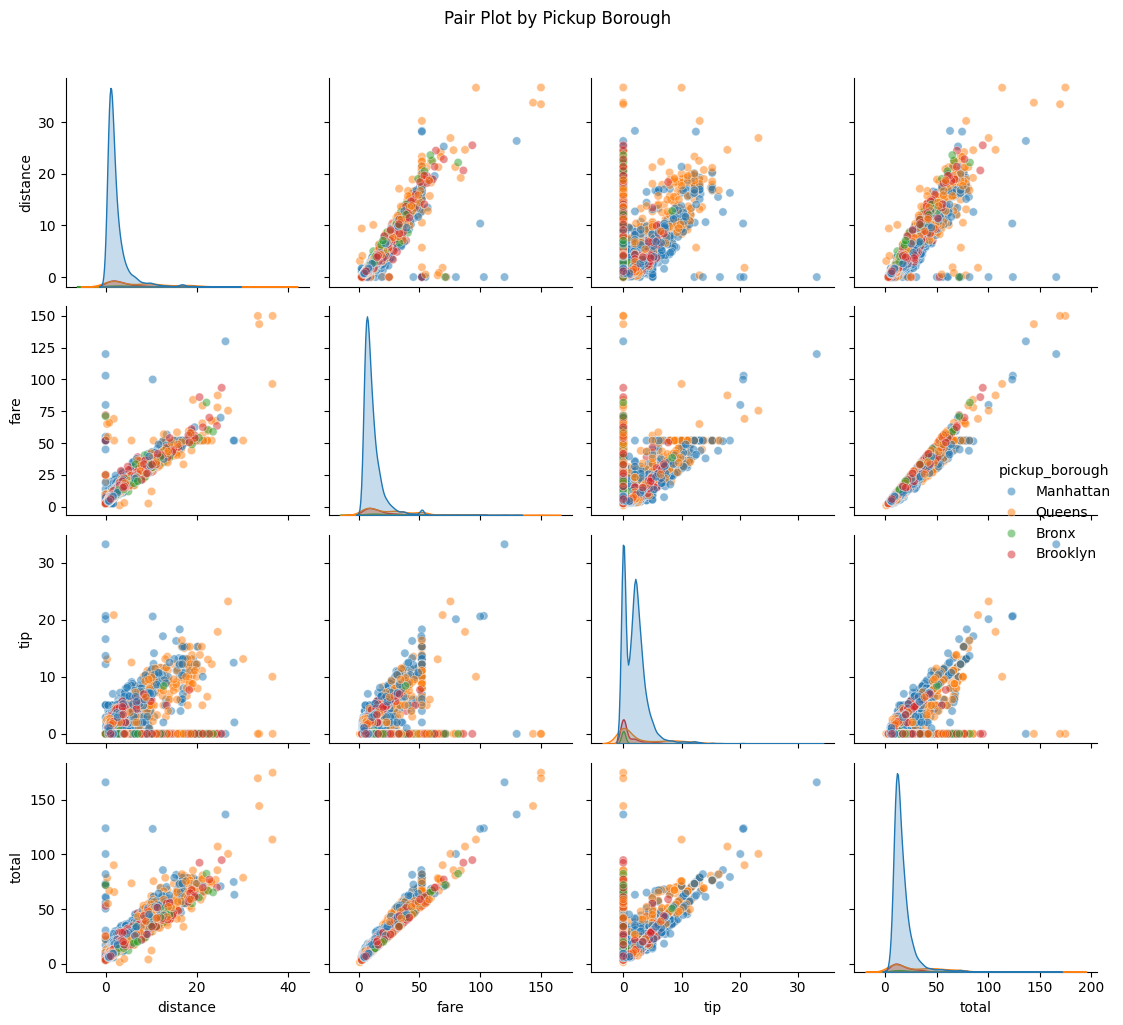

In [13]:
#Pair Plot
pair_df = df[['distance', 'fare', 'tip', 'total', 'pickup_borough']].copy()

g = sns.pairplot(pair_df, hue='pickup_borough',
             vars=['distance', 'fare', 'tip', 'total'],
             plot_kws={'alpha': 0.5}, height=2.5)

g.fig.suptitle('Pair Plot by Pickup Borough', y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1328/2728617201.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='payment', y='fare',


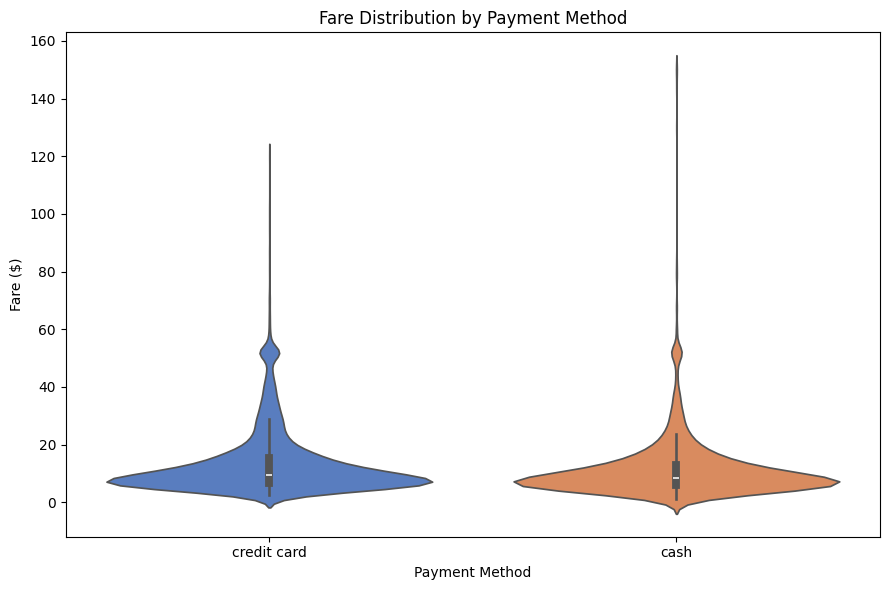

In [14]:
#Violin Plot
plt.figure(figsize=(9, 6))
sns.violinplot(data=df, x='payment', y='fare',
               palette='muted')
plt.title('Fare Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Fare ($)')
plt.tight_layout()
plt.show()